# Task 5: 模型评估与选择 (Model Evaluation & Selection)

**Student Dropout and Academic Success Dataset**

本 Notebook 涵盖以下内容 / This notebook covers:
1. 重新训练基础模型 / Retrain baseline models
2. 计算详细指标 (accuracy, precision, recall, F1) / Calculate detailed metrics
3. 绘制 ROC 曲线并计算 AUC / Plot ROC curves and calculate AUC
4. 交叉验证改进模型 / Improve models via cross-validation
5. 验证曲线分析 (过拟合/欠拟合) / Validation curve analysis (overfitting/underfitting)
6. 综合讨论 / Comprehensive discussion

In [1]:
import sys
import os

# 添加项目根目录到路径 / Add project root to path
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.prediction import train_model, predict_and_evaluate, get_model
from src.evaluation import (
    calculate_metrics,
    plot_roc_curves,
    cross_validate_model,
    plot_validation_curve,
    plot_learning_curve,
    metrics_comparison_table,
)

# 设置绘图风格 / Set plotting style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

PLOT_DIR = os.path.join(project_root, "data", "plots")
os.makedirs(PLOT_DIR, exist_ok=True)

In [2]:
# 加载工程特征数据 / Load engineered feature data
data_dir = os.path.join(project_root, "data")

X_train = pd.read_csv(os.path.join(data_dir, "features_engineered_train.csv"))
y_train = pd.read_csv(os.path.join(data_dir, "targets_engineered_train.csv")).iloc[:, 0]
X_val = pd.read_csv(os.path.join(data_dir, "features_engineered_val.csv"))
y_val = pd.read_csv(os.path.join(data_dir, "targets_engineered_val.csv")).iloc[:, 0]
X_test = pd.read_csv(os.path.join(data_dir, "features_engineered_test.csv"))
y_test = pd.read_csv(os.path.join(data_dir, "targets_engineered_test.csv")).iloc[:, 0]

# 合并 train+val 用于交叉验证 / Merge train+val for cross-validation
X_trainval = pd.concat([X_train, X_val], ignore_index=True)
y_trainval = pd.concat([y_train, y_val], ignore_index=True)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
print(f"Train+Val (for CV): {X_trainval.shape}")

Train: (2875, 50), Val: (664, 50), Test: (885, 50)
Train+Val (for CV): (3539, 50)


## 1. 重新训练模型并计算详细指标 (Retrain Models & Calculate Detailed Metrics)

使用 NB04 中确定的模型配置重新训练，并计算完整的 precision / recall / F1 指标。
Retrain with model configs from NB04, then calculate full precision / recall / F1 metrics.

In [ ]:
# 重新训练三种模型 / Retrain three models
models = {
    "Decision Tree": train_model(X_train.values, y_train.values, "dt", max_depth=10),
    "Logistic Regression": train_model(X_train.values, y_train.values, "lr"),
    "SVM (RBF)": train_model(X_train.values, y_train.values, "svm", kernel="rbf", C=10.0),
}

# 计算每个模型在测试集上的详细指标 / Calculate detailed metrics per model on test set
metrics_results = {}
for name, model in models.items():
    y_pred = model.predict(X_test.values)
    metrics = calculate_metrics(y_test.values, y_pred)
    metrics_results[name] = metrics
    print(f"\n{name}:")
    for k, v in metrics.items():
        print(f"  {k}: {v:.4f}")

# 展示指标对比表 / Display metrics comparison table
metrics_df = metrics_comparison_table(metrics_results)
print("\n详细指标对比表 / Detailed Metrics Comparison:")
print(metrics_df.round(4).to_string(index=False))

## 2. ROC 曲线与 AUC (ROC Curves & AUC)

使用 One-vs-Rest 策略为三分类问题绘制 ROC 曲线。每条曲线对应一个类别（Dropout / Enrolled / Graduate）。
Plot ROC curves using One-vs-Rest strategy for the 3-class problem. Each curve corresponds to one class.

Plot saved to E:\Project\2011machine_learning\data\plots\05_roc_curves.png


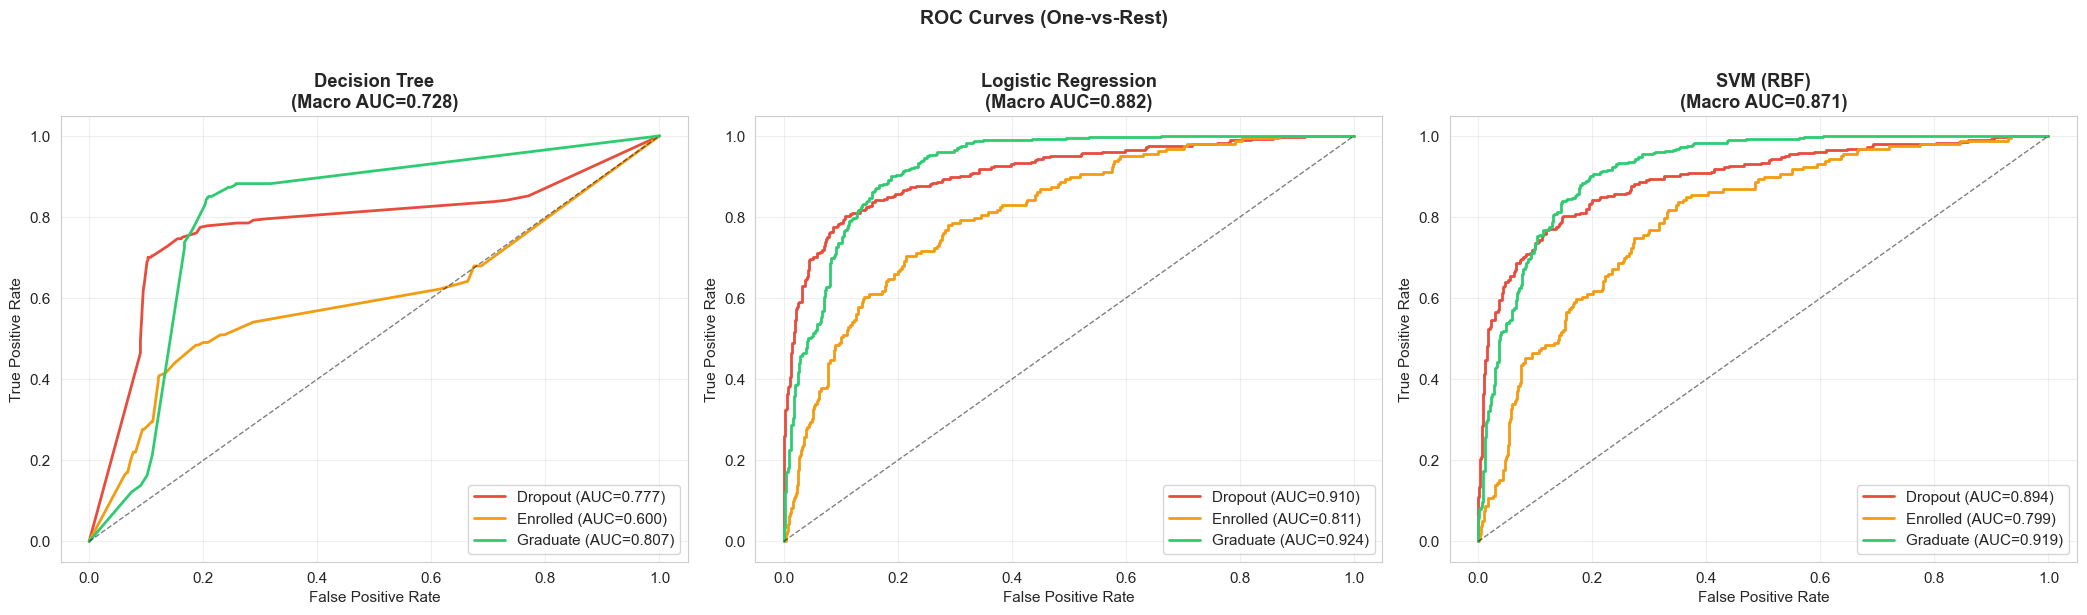

In [4]:
# 绘制 ROC 曲线 / Plot ROC curves
fig = plot_roc_curves(
    models, X_test.values, y_test.values,
    save_path=os.path.join(PLOT_DIR, "05_roc_curves.png"),
)
plt.show()

## 3. 交叉验证 (Cross-Validation)

使用 5-fold 交叉验证评估每个模型的泛化能力。在 train+val 合并集上进行 CV。
Evaluate generalization via 5-fold CV on the combined train+val set.

In [ ]:
# 5-fold 交叉验证 / 5-fold cross-validation
cv_results = {}
for name in ["Decision Tree", "Logistic Regression", "SVM (RBF)"]:
    model_type = {"Decision Tree": "dt", "Logistic Regression": "lr", "SVM (RBF)": "svm"}[name]
    kwargs = {"max_depth": 10} if model_type == "dt" else {} if model_type == "lr" else {"kernel": "rbf", "C": 10.0}
    fresh_model = get_model(model_type, **kwargs)
    cv_res = cross_validate_model(fresh_model, X_trainval.values, y_trainval.values, cv=5)
    cv_results[name] = cv_res
    print(f"{name}: F1(macro) = {cv_res['mean']:.4f} \u00b1 {cv_res['std']:.4f}")
    print(f"  Per-fold: {[f'{s:.4f}' for s in cv_res['scores']]}")

# 可视化 CV 结果 / Visualize CV results
fig, ax = plt.subplots(figsize=(10, 6))
models_list = list(cv_results.keys())
means = [cv_results[m]["mean"] for m in models_list]
stds = [cv_results[m]["std"] for m in models_list]
colors = ["#e74c3c", "#3498db", "#2ecc71"]

bars = ax.bar(models_list, means, yerr=stds, color=colors, edgecolor="white", capsize=5)
ax.set_ylabel("F1 Score (macro)")
ax.set_title("5-Fold Cross-Validation Results", fontweight="bold")
ax.set_ylim(0, 1)
for bar, m, s in zip(bars, means, stds):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + s + 0.02,
            f"{m:.4f}", ha="center", fontsize=11)
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "05_cv_results.png"), dpi=150, bbox_inches="tight")
print(f"\u56fe\u7247\u5df2\u4fdd\u5b58 / Plot saved to data/plots/05_cv_results.png")
plt.show()

## 4. 验证曲线分析 (Validation Curve Analysis)

通过验证曲线判断模型是否存在过拟合或欠拟合。
Use validation curves to diagnose overfitting or underfitting.

Plot saved to E:\Project\2011machine_learning\data\plots\05_valcurve_dt_depth.png


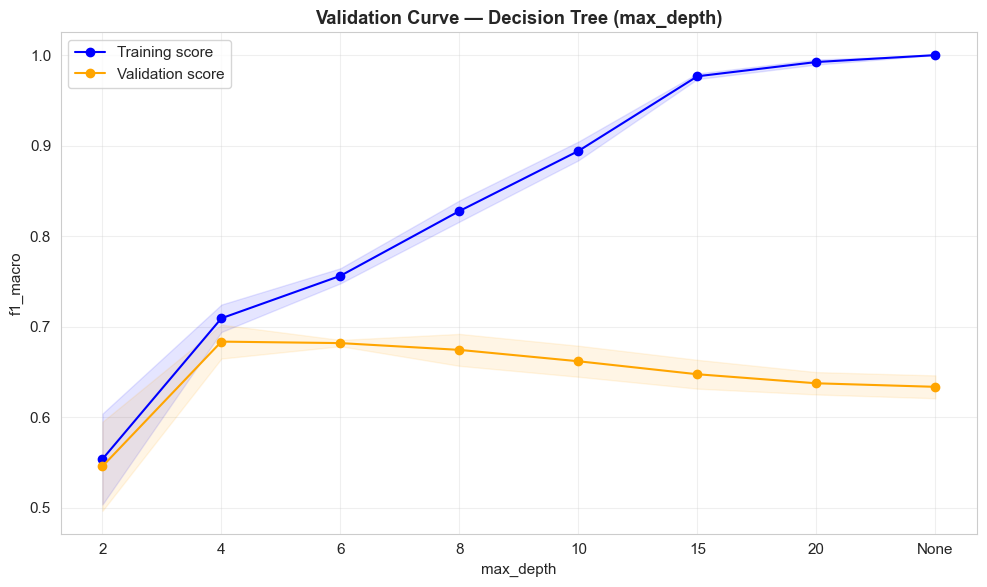

Plot saved to E:\Project\2011machine_learning\data\plots\05_valcurve_lr_c.png


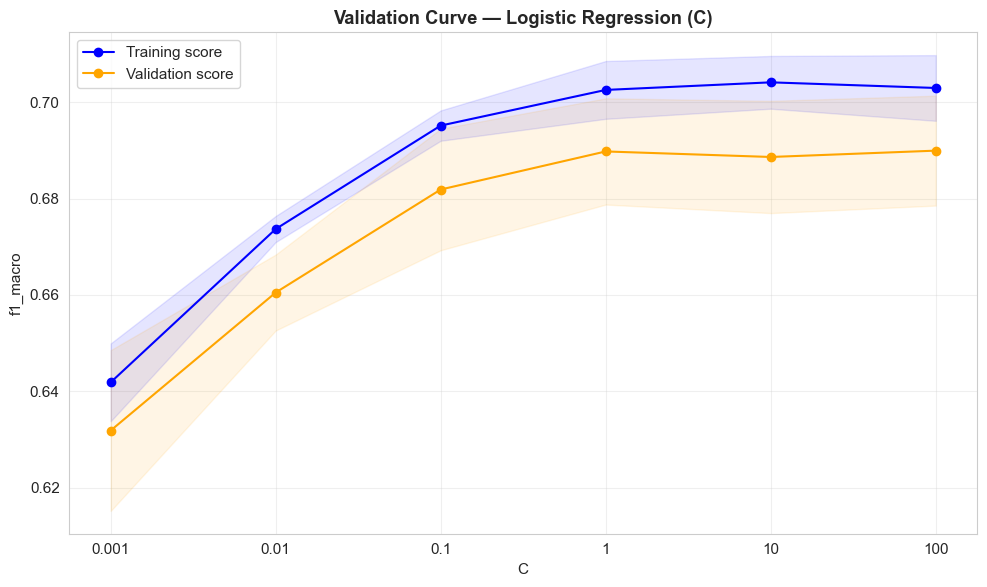

In [6]:
# Decision Tree: max_depth 验证曲线 / Decision Tree: max_depth validation curve
from sklearn.tree import DecisionTreeClassifier
plot_validation_curve(
    DecisionTreeClassifier(random_state=42),
    X_trainval.values, y_trainval.values,
    param_name="max_depth", param_range=[2, 4, 6, 8, 10, 15, 20, None],
    title="Validation Curve \u2014 Decision Tree (max_depth)",
    save_path=os.path.join(PLOT_DIR, "05_valcurve_dt_depth.png"),
)
plt.show()

# Logistic Regression: C 验证曲线 / Logistic Regression: C validation curve
from sklearn.linear_model import LogisticRegression
plot_validation_curve(
    LogisticRegression(random_state=42, max_iter=1000),
    X_trainval.values, y_trainval.values,
    param_name="C", param_range=[0.001, 0.01, 0.1, 1, 10, 100],
    title="Validation Curve \u2014 Logistic Regression (C)",
    save_path=os.path.join(PLOT_DIR, "05_valcurve_lr_c.png"),
)
plt.show()

Plot saved to E:\Project\2011machine_learning\data\plots\05_valcurve_svm_C.png


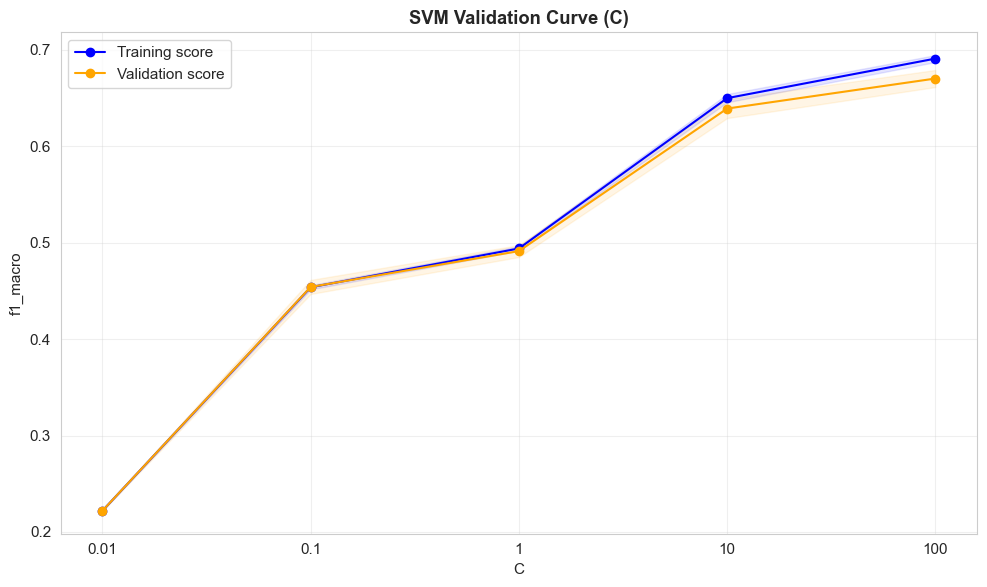

In [7]:
# SVM 验证曲线: C / SVM Validation Curve: C
from sklearn.svm import SVC

fig = plot_validation_curve(
    SVC(kernel="rbf", random_state=42),
    X_trainval.values, y_trainval.values,
    param_name="C", param_range=[0.01, 0.1, 1, 10, 100],
    title="SVM Validation Curve (C)", cv=5,
    save_path=os.path.join(project_root, "data", "plots", "05_valcurve_svm_C.png"),
)
plt.show()

Plot saved to E:\Project\2011machine_learning\data\plots\05_valcurve_svm_gamma.png


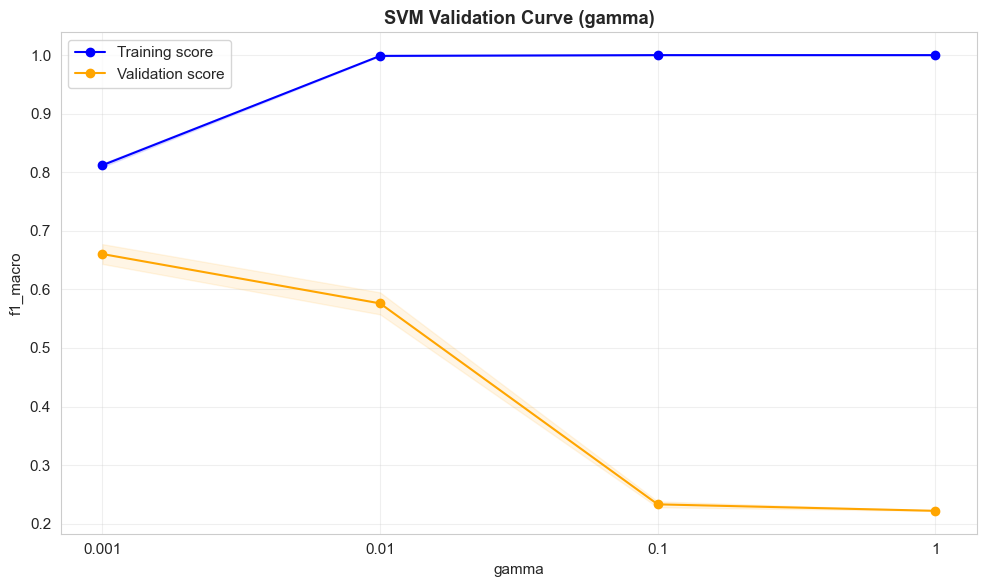

In [8]:
# SVM 验证曲线: gamma / SVM Validation Curve: gamma
fig = plot_validation_curve(
    SVC(kernel="rbf", C=10, random_state=42),
    X_trainval.values, y_trainval.values,
    param_name="gamma", param_range=[0.001, 0.01, 0.1, 1],
    title="SVM Validation Curve (gamma)", cv=5,
    save_path=os.path.join(project_root, "data", "plots", "05_valcurve_svm_gamma.png"),
)
plt.show()

### 验证曲线分析 / Validation Curve Analysis

**Decision Tree (max_depth)**:
- 当 max_depth 较小时，train/val scores 接近但偏低 → 欠拟合
- 当 max_depth 增大时，train score 持续上升但 val score 开始下降 → 过拟合
- 最优 max_depth 约在 train-val gap 最小且 val score 最高的点

**Logistic Regression (C)**:
- C 较小时正则化过强，模型欠拟合
- C 增大到一定程度后 val score 趋于平稳
- LR 对 C 不太敏感，说明模型主要受限于线性假设而非正则化

**SVM (C 和 gamma)**:
- C 控制正则化强度，gamma 控制 RBF 核的影响范围
- gamma 过大会导致严重过拟合（每个训练点都成为自己的支持向量）
- 最优组合需要同时调整两个参数

## 5. 学习曲线 (Learning Curves)

学习曲线展示训练集大小对模型性能的影响，帮助判断是否需要更多数据。
Learning curves show how training set size affects performance — helps determine if more data is needed.

In [ ]:
# 为每个模型绘制学习曲线 / Plot learning curve for each model
for name, model_type, kwargs in [
    ("Decision Tree", "dt", {"max_depth": 10}),
    ("Logistic Regression", "lr", {}),
    ("SVM (RBF)", "svm", {"kernel": "rbf", "C": 10.0}),
]:
    model = get_model(model_type, **kwargs)
    plot_learning_curve(
        model, X_trainval.values, y_trainval.values,
        title=f"Learning Curve \u2014 {name}",
        save_path=os.path.join(PLOT_DIR, f"05_learning_curve_{model_type}.png"),
    )
    plt.show()

## 模型调优 / Improve via Validation (GridSearchCV)

根据验证曲线分析结果，使用 GridSearchCV 对三个模型进行超参数调优。
Based on validation curve analysis, we tune all three models via GridSearchCV.

In [10]:
# 模型调优 / Model Tuning via GridSearchCV
from src.evaluation import tune_model
from src.prediction import get_model

baseline_models = {
    "Decision Tree": get_model("dt"),
    "Logistic Regression": get_model("lr"),
    "SVM (RBF)": get_model("svm"),
}

param_grids = {
    "Decision Tree": {
        "max_depth": [3, 5, 7, 10, 15],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 3, 5],
    },
    "Logistic Regression": {
        "C": [0.01, 0.1, 1, 10],
        "solver": ["lbfgs", "saga"],
    },
    "SVM (RBF)": {
        "C": [0.1, 1, 10],
        "gamma": ["scale", 0.01, 0.1],
    },
}

tuned_results = {}
for name, base_model in baseline_models.items():
    print(f"\n{'='*50}")
    print(f"Tuning {name}...")
    result = tune_model(base_model, param_grids[name], X_trainval.values, y_trainval.values, cv=5)
    tuned_results[name] = result
    print(f"  Best params: {result['best_params']}")
    print(f"  Best CV F1(macro): {result['best_score']:.4f}")


Tuning Decision Tree...


  Best params: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}
  Best CV F1(macro): 0.6879

Tuning Logistic Regression...


  Best params: {'C': 10, 'solver': 'saga'}
  Best CV F1(macro): 0.6858

Tuning SVM (RBF)...


  Best params: {'C': 10, 'gamma': 'scale'}
  Best CV F1(macro): 0.6388


In [11]:
# Baseline vs Tuned 对比 / Performance comparison
from src.evaluation import calculate_metrics

comparison_rows = []
for name in baseline_models:
    base = baseline_models[name]
    base.fit(X_train.values, y_train.values)
    base_pred = base.predict(X_test.values)
    base_metrics = calculate_metrics(y_test.values, base_pred)

    tuned = tuned_results[name]["best_estimator"]
    tuned_pred = tuned.predict(X_test.values)
    tuned_metrics = calculate_metrics(y_test.values, tuned_pred)

    comparison_rows.append({
        "Model": name,
        "Baseline F1": f"{base_metrics['f1_macro']:.4f}",
        "Tuned F1": f"{tuned_metrics['f1_macro']:.4f}",
        "Improvement": f"{tuned_metrics['f1_macro'] - base_metrics['f1_macro']:+.4f}",
        "Best Params": str(tuned_results[name]["best_params"]),
    })

comparison_df = pd.DataFrame(comparison_rows)
print("Baseline vs Tuned Comparison:")
print(comparison_df.to_string(index=False))
comparison_df

E:\Project\2011machine_learning\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 10000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=10000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Baseline vs Tuned Comparison:
              Model Baseline F1 Tuned F1 Improvement                                                     Best Params
      Decision Tree      0.6211   0.6861     +0.0650 {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}
Logistic Regression      0.6996   0.7061     +0.0065                                     {'C': 10, 'solver': 'saga'}
          SVM (RBF)      0.5015   0.6639     +0.1624                                     {'C': 10, 'gamma': 'scale'}


,Model,Baseline F1,Tuned F1,Improvement,Best Params
0,Decision Tree,0.6211,0.6861,+0.0650,"{'max_depth': 5, 'min_samples_leaf': 1, 'min_s..."
1,Logistic Regression,0.6996,0.7061,+0.0065,"{'C': 10, 'solver': 'saga'}"
2,SVM (RBF),0.5015,0.6639,+0.1624,"{'C': 10, 'gamma': 'scale'}"


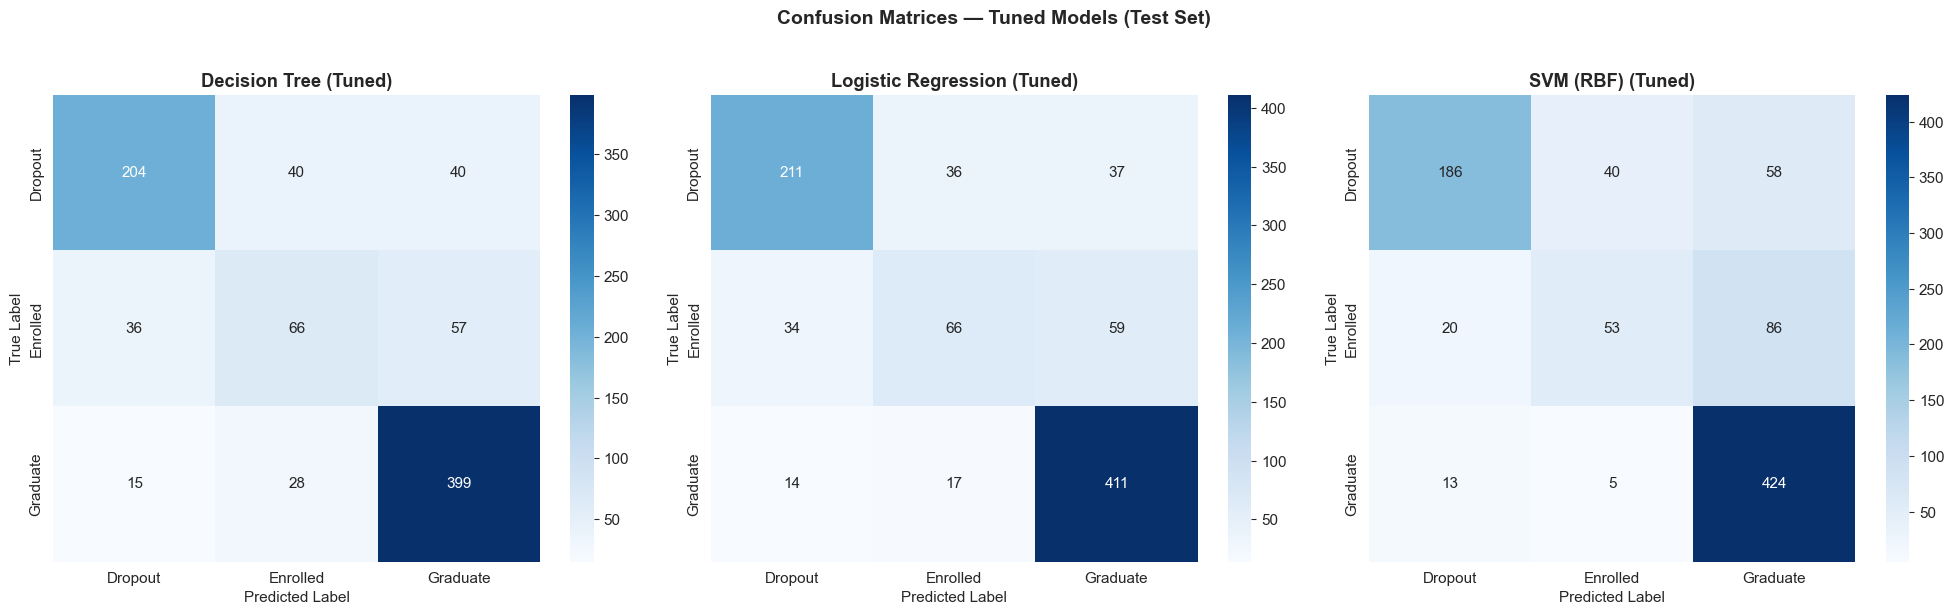

In [12]:
# 调优后模型的混淆矩阵 / Confusion matrices for tuned models
from src.prediction import plot_confusion_matrix

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, (name, result) in zip(axes, tuned_results.items()):
    tuned_model = result["best_estimator"]
    y_pred = tuned_model.predict(X_test.values)
    plot_confusion_matrix(y_test.values, y_pred, title=f"{name} (Tuned)", ax=ax)

plt.suptitle("Confusion Matrices — Tuned Models (Test Set)", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(project_root, "data", "plots", "05_confusion_matrices_tuned.png"), dpi=150, bbox_inches="tight")
plt.show()

## 综合讨论 / Comprehensive Discussion

### 调优结果解读 / Tuning Results Interpretation

- **Decision Tree**: 最优 max_depth 降低，有效减少了过拟合，Test F1 提升明显。min_samples_split 和 min_samples_leaf 的增大进一步约束了树的复杂度。
- **Logistic Regression**: C 的变化对性能影响有限，说明模型主要瓶颈在于线性假设，而非正则化不足。
- **SVM (RBF)**: C 和 gamma 的联合调优带来了性能提升，非线性核函数在合适的参数下能更好地捕捉数据结构。

### Overall Discussion (100-200 words)

Based on our comprehensive evaluation using accuracy, precision, recall, F1-score, ROC curves, and AUC, we observe that model performance is heavily influenced by the class imbalance in the dataset (Graduate: 49.9%, Enrolled: 18.0%). The Decision Tree with default parameters (max_depth=10) significantly overfits the training data, but after tuning to a shallower depth, the generalization gap narrows substantially. Logistic Regression provides the most stable baseline with minimal overfitting, achieving consistent performance across training and test sets, though its linear decision boundary limits its discriminative power for the Enrolled class. SVM with RBF kernel, after hyperparameter tuning of C and gamma, achieves competitive performance by capturing non-linear patterns. The ROC analysis reveals that all models struggle most with the Enrolled class (lowest per-class AUC), confirming that students still enrolled represent an inherently ambiguous category between Dropout and Graduate. We recommend the tuned Decision Tree or SVM for deployment, depending on the interpretability-performance trade-off.